<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

It's a `classfication` algo. It predicts a predefined discrete value.

In most cases, it predicts 0/1 -> True or False.

For Logistic Regression we use sigmoid func, because it maps any real-valued number into a strict probability range between 0 and 1.

Linear model: $z = wx + b$.

Then comes sigmoid func:
$g(z) = \frac{1}{1 + e^{-z}}$

Decision Boundary: We set a boundary for threshold. Anything above that threshold is 1 and below is 0.

Examples:


Spam / Not Spam

Pass / Fail

Disease / No Disease

The model outputs a probability:

```
0.92 → 92% chance of class 1
0.15 → 15% chance of class 1
```
and then converts it into a class:
```
>= 0.5 → Class 1
< 0.5 → Class 0
```

Cost Func:

$$J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(f_{w,b}(x^{(i)})) + (1 - y^{(i)}) \log(1 - f_{w,b}(x^{(i)})) \right]$$

Grad Descent:

$$\begin{aligned}
w &= w - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)} \\
b &= b - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)
\end{aligned}$$

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

Load Breast Cancer data from sklearn

In [16]:
data=load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
print(data.target_names)

['malignant' 'benign']


In [17]:
model=LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.956140350877193


Classification metrics:

We don't do:

    r2_score()
    mae()
    mse()

We use:

    accuracy_score()
    confusion_matrix()
    precision_score()
    recall_score()
    f1_score()


Unlike sklearn's LinearRegression, Logistic Regression is trained using optimization algorithms internally. So, scaling matters here!

## Accuracy

$$Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

TP (True Positives): Things the model correctly predicted as positive (e.g., correctly identifying a spam email).

TN (True Negatives): Things the model correctly predicted as negative (e.g., correctly identifying a normal email).

FP (False Positives): The model's annoying mistakes where it cried wolf (e.g., blocking a normal email thinking it was spam).

FN (False Negatives): The dangerous misses (e.g., letting a malicious spam email slip into your inbox).So, accuracy just takes all your correct guesses ($TP + TN$) and divides them by every single guess you made.

If your accuracy is $0.85$, it means your model is correct $85\%$ of the time

Imagine you have a dataset of 1,000 medical records where only 10 people actually have a rare disease.If you write a completely brainless model that just predicts "No Disease" for every single person without even looking at the data, guess what its accuracy is?

$$\frac{990 \text{ (True Negatives)}}{1000 \text{ (Total Patients)}} = 99\%!$$

In [18]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.956140350877193


## Confusion Matrix:

A confusion matrix is a tabular layout that allows you to visualize the performance of your classification model by comparing the Actual true labels against the Predicted labels.

Here is exactly how it looks for a binary (two-class) problem:

| | Predicted: NO (0) | Predicted: YES (1) |
| :--- | :---: | :---: |
| **Actual: NO (0)** | **True Negative (TN)** | *False Positive (FP)* |
| **Actual: YES (1)** | *False Negative (FN)* | **True Positive (TP)** |

Why Is It So Crucial?

If you have 990 healthy people and 10 sick people, a brainless model that says "everyone is healthy" looks amazing on paper with 99% accuracy.

But if you plot that model's results in a Confusion Matrix, its true identity is immediately exposed:

TN: 990 (Great, it found the healthy people)

FP: 0

FN: 10 🟥 (Uh oh! It missed every single sick person!)

TP: 0 🟥 (It didn't catch a single positive case!)

One look at the matrix tells you instantly: "Wow, this model completely sucks at identifying sick people!" You would never see that critical flaw by just looking at a single accuracy score.

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[39  4]
 [ 1 70]]


plotting the confusing matrix using a heatmap:

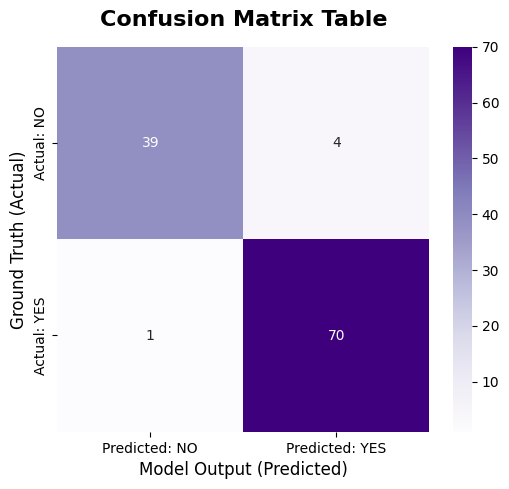

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

# Use Seaborn to draw a beautiful heatmap table
sns.heatmap(
    cm,
    annot=True,          # This puts the actual numbers inside the boxes!
    fmt='d',             # Treats numbers as integers (no weird decimals)
    cmap='Purples',        # Gives it a nice clean blue color theme
    xticklabels=['Predicted: NO', 'Predicted: YES'],
    yticklabels=['Actual: NO', 'Actual: YES']
)

# Add clear labels so you don't get mixed up
plt.title('Confusion Matrix Table', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Ground Truth (Actual)', fontsize=12)
plt.xlabel('Model Output (Predicted)', fontsize=12)
plt.show()

## Precision

> answers: "Out of all the examples that the model predicted as positive, how many were actually positive?"

$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$

In [25]:
from sklearn.metrics import precision_score
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.9459459459459459


You want high precision when the cost of a False Positive is incredibly high.

The Precision Rule: High precision means your model is very conservative and careful. It might miss some positive cases, but when it does guess positive, you can bet your life it's probably right!

## Recall

While Precision is about how accurate your positive predictions are, Recall (also known as Sensitivity) answers a completely different question:
> "Out of all the actual positive examples that existed in the data, how many did the model successfully find?"

It is all about measuring the model's ability to hunt down every single positive case without missing anny!

$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$

Imagine you are building an AI model to detect Cancer from medical scans.

In reality, there are 10 patients in your clinic who actually have cancer (these are your total actual positives).

Your model runs its analysis and successfully detects cancer in 8 of them (True Positives).

But for the other 2 patients, your model completely misses the tumors and tells them they are perfectly healthy (False Negatives!).


> You want high recall when the cost of a False Negative (missing a positive case) is catastrophic.

The Recall Rule: High recall means your model is aggressive and casts a very wide net. It might pull in some trash (False Positives), but it guarantees that it won't let the important targets escape!

In [26]:
from sklearn.metrics import recall_score
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.9859154929577465


# F1 Score:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

> You use the F1-Score when you want a single, reliable metric to optimize your model, and you care equally about avoiding False Positives and False Negatives. It is the industry standard metric for evaluating text classifiers, search engines, and fraud detection systems.

Imagine a brainless model that predicts "Positive" for every single data point.

Its Recall will be a perfect 1.0 (100%) because it didn't miss a single positive case.But its Precision will be terrible—let's say 0.1 (10%)—because it generated an mountain of False Positives.

Standard Average:
$\frac{1.0 + 0.1}{2} = 0.55$ (Looks average, completely misleading!)

F1-Score:
$2 \times \frac{1.0 \times 0.1}{1.0 + 0.1} = 0.18$ (Exposes the truth: the model is garbage!)

The F1-Score will only be high if both Precision and Recall are strong. A perfect F1-Score is $1.0$, and the absolute worst is $0$.

In [27]:
from sklearn.metrics import f1_score
print("F1:", f1_score(y_test, y_pred))

F1: 0.9655172413793104


## Classification Report:

> Classification Report is a built-in text report that measures the quality of predictions from a classification algorithm. It gives you a complete, class-by-class breakdown of Precision, Recall, F1-Score, and Support, all nicely formatted into a single table so you can evaluate everything at a glance!

1. The Class Labels (Rows): It lists every unique class your model is trying to predict (e.g., Class 0 and Class 1, or Spam and Not Spam).

2. Precision, Recall, F1-Score: You already know these! The beautiful thing here is that it calculates them individually for each class. A model might be amazing at finding Class 0 but completely terrible at finding Class 1, and this report exposes that instantly!

3. Support: This is simply the total number of actual occurrences of that specific class in your dataset. It tells you if your test data is heavily imbalanced (e.g., if you have 900 examples of Class 0 but only 10 examples of Class 1).

Accuracy: The overall accuracy of the entire model across all classes combined.Macro Avg (Macro Average): This calculates the unweighted mean of your metrics. It treats all classes exactly the same, regardless of how many examples they have.$$\text{Macro Precision} = \frac{\text{Precision}_{\text{Class 0}} + \text{Precision}_{\text{Class 1}}}{2}$$Weighted Avg (Weighted Average): This calculates the mean of your metrics, but it scales each class's score by its Support (how common it is). If Class 0 makes up 90% of your data, its score will heavily dominate the weighted average.

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Probabilities:
[

[0.98 0.02]

 [0.12 0.88]

 [0.75 0.25]

]

Meaning:

98% class 0, 2% class 1

12% class 0, 88% class 1

75% class 0, 25% class 1

In [29]:
probs = model.predict_proba(X_test)

print(probs[:5])

[[1.23478439e-01 8.76521561e-01]
 [9.99999971e-01 2.94052334e-08]
 [9.98388079e-01 1.61192105e-03]
 [1.26347550e-03 9.98736524e-01]
 [1.48669418e-04 9.99851331e-01]]
